In [26]:
import pprint
import radiate as rd
import numpy as np
import polars as pl

rd.random.seed(123)

In [27]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

x = -1.0
for _ in range(20):
    x += 0.1
    inputs.append([x])
    answers.append([compute(x)])

X = np.array(inputs, dtype=np.float32)  # (N, 1)
Y = np.array(answers, dtype=np.float32)  # (N, 1)

Xb = np.concatenate([X, np.ones((X.shape[0], 1), dtype=np.float32)], axis=1)


def fit(weights: list[np.ndarray]) -> float:
    W1 = weights[0].reshape((8, 2))
    W2 = weights[1].reshape((8, 8))
    W3 = weights[2].reshape((1, 8))

    h1 = Xb @ W1.T
    h1 = np.maximum(0, h1)

    h2 = h1 @ W2
    h2 = np.tanh(h2)

    yhat = h2 @ W3.T

    return float(np.mean((yhat - Y) ** 2, dtype=np.float32))

In [ ]:
collector = rd.MetricCollector()

best_score = rd.metric("scores").min()

sma_5 = best_score.rolling(5).mean()
sma_10 = best_score.rolling(10).mean()
sma_20 = best_score.rolling(20).mean()

sma_10_stddev = best_score.rolling(10).stddev()

score_stddev = rd.metric("scores").min().rolling(10).stddev()
slope = rd.metric("scores.best").rolling(10).slope()
slope_div = rd.metric("rate.diversity").rolling(10).slope()

progress = ((sma_20 - sma_5) / (sma_20 + rd.lit(1e-6))).clamp(0.0, 1.0)
diversity = rd.metric("rate.diversity").rolling(10).mean().clamp(0.0, 1.0)
flatness = (rd.lit(0.001) - abs(slope)).clamp(0.0, 1.0)
div_collapse = (rd.lit(0.0) - slope_div).clamp(0.0, 1.0)
low_volatility = (rd.lit(0.05) - score_stddev).clamp(0.0, 1.0)

w0, w1, w2, w3, w4, w5 = 0.02, 0.5, 0.4, 0.4, 0.4, 0.4

pressure = (
    rd.lit(w0)
    + rd.lit(w1) * (rd.lit(0.2) - progress)
    + rd.lit(w2) * (rd.lit(0.7) - diversity)
    + rd.lit(w3) * div_collapse
    + rd.lit(w4) * flatness
    + rd.lit(w5) * (rd.lit(0.05) - low_volatility)
).clamp(0.0, 1.0)

engine = (
    rd.Engine.float(
        shape=[16, 64, 8],
        init_range=(-1.0, 1.0),
        bounds=(-3.0, 3.0),
        use_numpy=True,
        dtype=rd.Float32,
    )
    .fitness(fit)
    .subscribe(collector)
    .minimizing()
    .metrics(
        progress=pressure,
    )
    .select(rd.Select.boltzmann(temp=4.0))
    .alters(rd.Cross.blend(0.7, 0.4), rd.Mutate.gaussian(0.3))
    .limit(rd.Limit.score(0.01), rd.Limit.generations(500))
)

result = engine.run(log=True)

2026-04-13T14:32:59.492991Z  INFO Epoch 1    | Score:   1.3453 | Time: 2.75ms
2026-04-13T14:32:59.494584Z  INFO Epoch 2    | Score:   1.1824 | Time: 4.26ms
2026-04-13T14:32:59.496073Z  INFO Epoch 3    | Score:   1.1824 | Time: 5.64ms
2026-04-13T14:32:59.497586Z  INFO Epoch 4    | Score:   0.7367 | Time: 7.06ms
2026-04-13T14:32:59.498650Z  INFO Epoch 5    | Score:   0.6363 | Time: 8.05ms
2026-04-13T14:32:59.499562Z  INFO Epoch 6    | Score:   0.5327 | Time: 8.93ms
2026-04-13T14:32:59.500447Z  INFO Epoch 7    | Score:   0.4152 | Time: 9.78ms
2026-04-13T14:32:59.501433Z  INFO Epoch 8    | Score:   0.3731 | Time: 10.72ms
2026-04-13T14:32:59.502822Z  INFO Epoch 9    | Score:   0.3731 | Time: 11.96ms
2026-04-13T14:32:59.504088Z  INFO Epoch 10   | Score:   0.3731 | Time: 13.16ms
2026-04-13T14:32:59.505284Z  INFO Epoch 11   | Score:   0.2171 | Time: 14.31ms
2026-04-13T14:32:59.506655Z  INFO Epoch 12   | Score:   0.2171 | Time: 15.63ms
2026-04-13T14:32:59.507840Z  INFO Epoch 13   | Score:   0.2

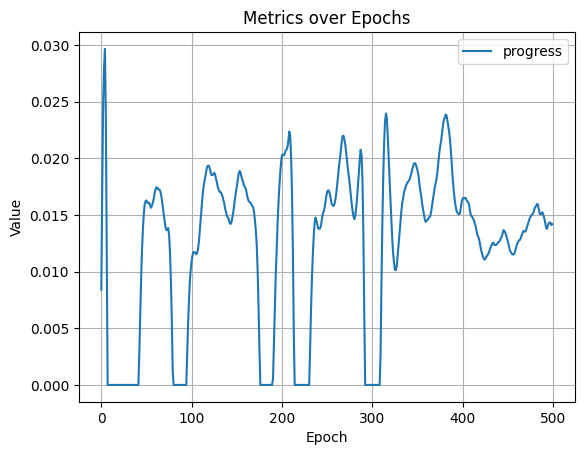

In [29]:
collector.plot(
    "progress",
)

In [30]:
metrics = result.metrics()
df = metrics.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""time""",0.0,null,null,null,null,null,null,null,500,476095µs,952µs,376µs,838µs,6671µs,0µs,499,1,"[""time""]"
"""alter.parent_reuse""",2.0,66878.0,2.620406,4.818197,23.215019,5.922647,1.0,69.0,25522,null,null,null,null,null,null,499,61,"[""alterer"", ""statistic"", … ""lineage""]"
"""step.filter""",0.0,null,null,null,null,null,null,null,500,3533µs,7µs,3µs,5µs,59µs,0µs,499,1,"[""time"", ""step""]"
"""score.improvement""",1.0,16.0,1.0,0.0,0.0,0.0,1.0,1.0,16,null,null,null,null,null,null,314,1,"[""statistic"", ""score""]"
"""selector.boltzmann""",80.0,40000.0,80.0,0.0,0.0,0.0,80.0,80.0,500,7799µs,15µs,4µs,13µs,55µs,0µs,499,2,"[""selector"", ""statistic"", ""time""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""lineage.events""",80.0,40000.0,80.0,0.0,0.0,0.0,80.0,80.0,500,null,null,null,null,null,null,499,1,"[""age"", ""statistic"", ""lineage""]"
"""rate.diversity""",0.96,479.869995,0.95974,0.019578,0.000383,0.0,0.89,1.0,500,null,null,null,null,null,null,499,1,"[""derived"", ""statistic"", ""rate""]"
"""age.replace""",1.0,1.0,1.0,0.0,0.0,NaN,1.0,1.0,1,null,null,null,null,null,null,236,1,"[""failure"", ""age"", ""statistic""]"


In [31]:
print(result.metrics().dashboard())
# pprint.pprint(metrics["carryover_rate"].tags())

for metric in metrics.values_by_tag(rd.Tag.DERIVED):
    print(metric)

print()
pprint.pprint(metrics["carryover_rate"].to_dict())

[36 metrics, 17018 updates]
----- Metrics -----
  carryover: 0.166  diversity: 0.960  unique_members: 96  unique_scores: 96  improvements: 16  iter_time(mean): 952.191µs

== Statistics ==
Name                     | Type   | Mean       | Min        | Max        | N      | Total        | StdDev     | Skew       | Kurt       | Entr      
-------------------------------------------------------------------------------------------------------------------------------------------------
age                      | value  | 0.402      | 0.000      | 20.000     | 50000  | -            | 1.313      | 25.337     | 379.131    | -         
age.replace              | value  | 1.000      | 1.000      | 1.000      | 1      | -            | 0.000      | NaN        | NaN        | -         
alter.cross_family       | value  | 45.249     | 1.000      | 63.000     | 594    | -            | 19.399     | -1.713     | 4.196      | -         
alter.parent_reuse       | value  | 2.620      | 1.000      | 69.000  

AttributeError: 'NoneType' object has no attribute 'to_dict'

In [ ]:
df = collector.to_polars(lazy=False)

df = (
    df.filter(
        (pl.col("update_count") > 1) & (~pl.col("tags").list.contains("distribution"))
    )
    .select("name", "version", "update_count", "tags")
    .group_by("name")
    .agg(
        pl.col("update_count").sum().alias("update_count"),
    )
    .sort("update_count", descending=False)
)

df

name,update_count
str,i64
"""evaluation_count""",2
"""blend_crossover""",998
"""gaussian_mutator""",998
"""roulette_selector""",1000
"""boltzmann_selector""",1000
"""evaluate_step""",1000


In [ ]:
df = collector.to_polars(lazy=False)


In [ ]:
df.filter(pl.col("name") == "gaussian_mutator")

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""gaussian_mutator""",2115.0,2115.0,2115.0,0.0,0.0,NaN,2115.0,2115.0,1,87µs,87µs,0µs,87µs,87µs,0µs,1,0,"[""alterer"", ""mutator"", … ""time""]"
"""gaussian_mutator""",2083.0,4198.0,2099.0,22.627417,512.0,NaN,2083.0,2115.0,2,172µs,86µs,2µs,84µs,87µs,0µs,2,2,"[""alterer"", ""mutator"", … ""time""]"
"""gaussian_mutator""",2100.0,6298.0,2099.333252,16.010414,256.333344,-0.346677,2083.0,2115.0,3,249µs,83µs,5µs,76µs,87µs,0µs,3,2,"[""alterer"", ""mutator"", … ""time""]"
"""gaussian_mutator""",2086.0,8384.0,2096.0,14.674222,215.332779,1.221628,2083.0,2115.0,4,320µs,80µs,7µs,71µs,87µs,0µs,4,2,"[""alterer"", ""mutator"", … ""time""]"
"""gaussian_mutator""",2086.0,10470.0,2094.0,13.472178,181.499588,1.713732,2083.0,2115.0,5,399µs,79µs,6µs,71µs,87µs,0µs,5,2,"[""alterer"", ""mutator"", … ""time""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""gaussian_mutator""",2129.0,1.047143e6,2111.175293,37.73447,1423.890259,-0.073169,1998.0,2210.0,496,35496µs,71µs,3µs,67µs,104µs,0µs,496,2,"[""alterer"", ""mutator"", … ""time""]"
"""gaussian_mutator""",2091.0,1.049234e6,2111.134766,37.707275,1421.838623,-0.070234,1998.0,2210.0,497,35566µs,71µs,3µs,67µs,104µs,0µs,497,2,"[""alterer"", ""mutator"", … ""time""]"
"""gaussian_mutator""",2016.0,1.05125e6,2110.943848,37.909782,1437.151611,-0.08579,1998.0,2210.0,498,35635µs,71µs,3µs,67µs,104µs,0µs,498,2,"[""alterer"", ""mutator"", … ""time""]"
